Cargando artefactos...

1. TABLAS DE MÉTRICAS

TABLA COMPARATIVA DE MÉTRICAS (°C)

Métricas globales:
 Modelo Split  MAE (°C)  RMSE (°C)     R²
A3T-GCN train    0.5022     0.7136 0.9615
A3T-GCN   val    0.5151     0.7320 0.9552
A3T-GCN  test    0.5251     0.7522 0.9544
  DCRNN train    0.3306     0.4800 0.9826
  DCRNN   val    0.3721     0.5465 0.9750
  DCRNN  test    0.3906     0.5781 0.9731

Métricas por estación (TEST):

MAE (°C) por estación:
Modelo      A3T-GCN   DCRNN
estacion                   
Belisario    0.5495  0.3932
Carapungo    0.5074  0.3808
Cotocollao   0.4999  0.3799
ElCamal      0.5612  0.3784
LosChillos   0.5347  0.4243
Tumbaco      0.5142  0.3819

R² por estación:
Modelo      A3T-GCN   DCRNN
estacion                   
Belisario    0.9398  0.9664
Carapungo    0.9505  0.9701
Cotocollao   0.9439  0.9642
ElCamal      0.9083  0.9573
LosChillos   0.9577  0.9724
Tumbaco      0.9615  0.9775

2. CURVAS DE CONVERGENCIA


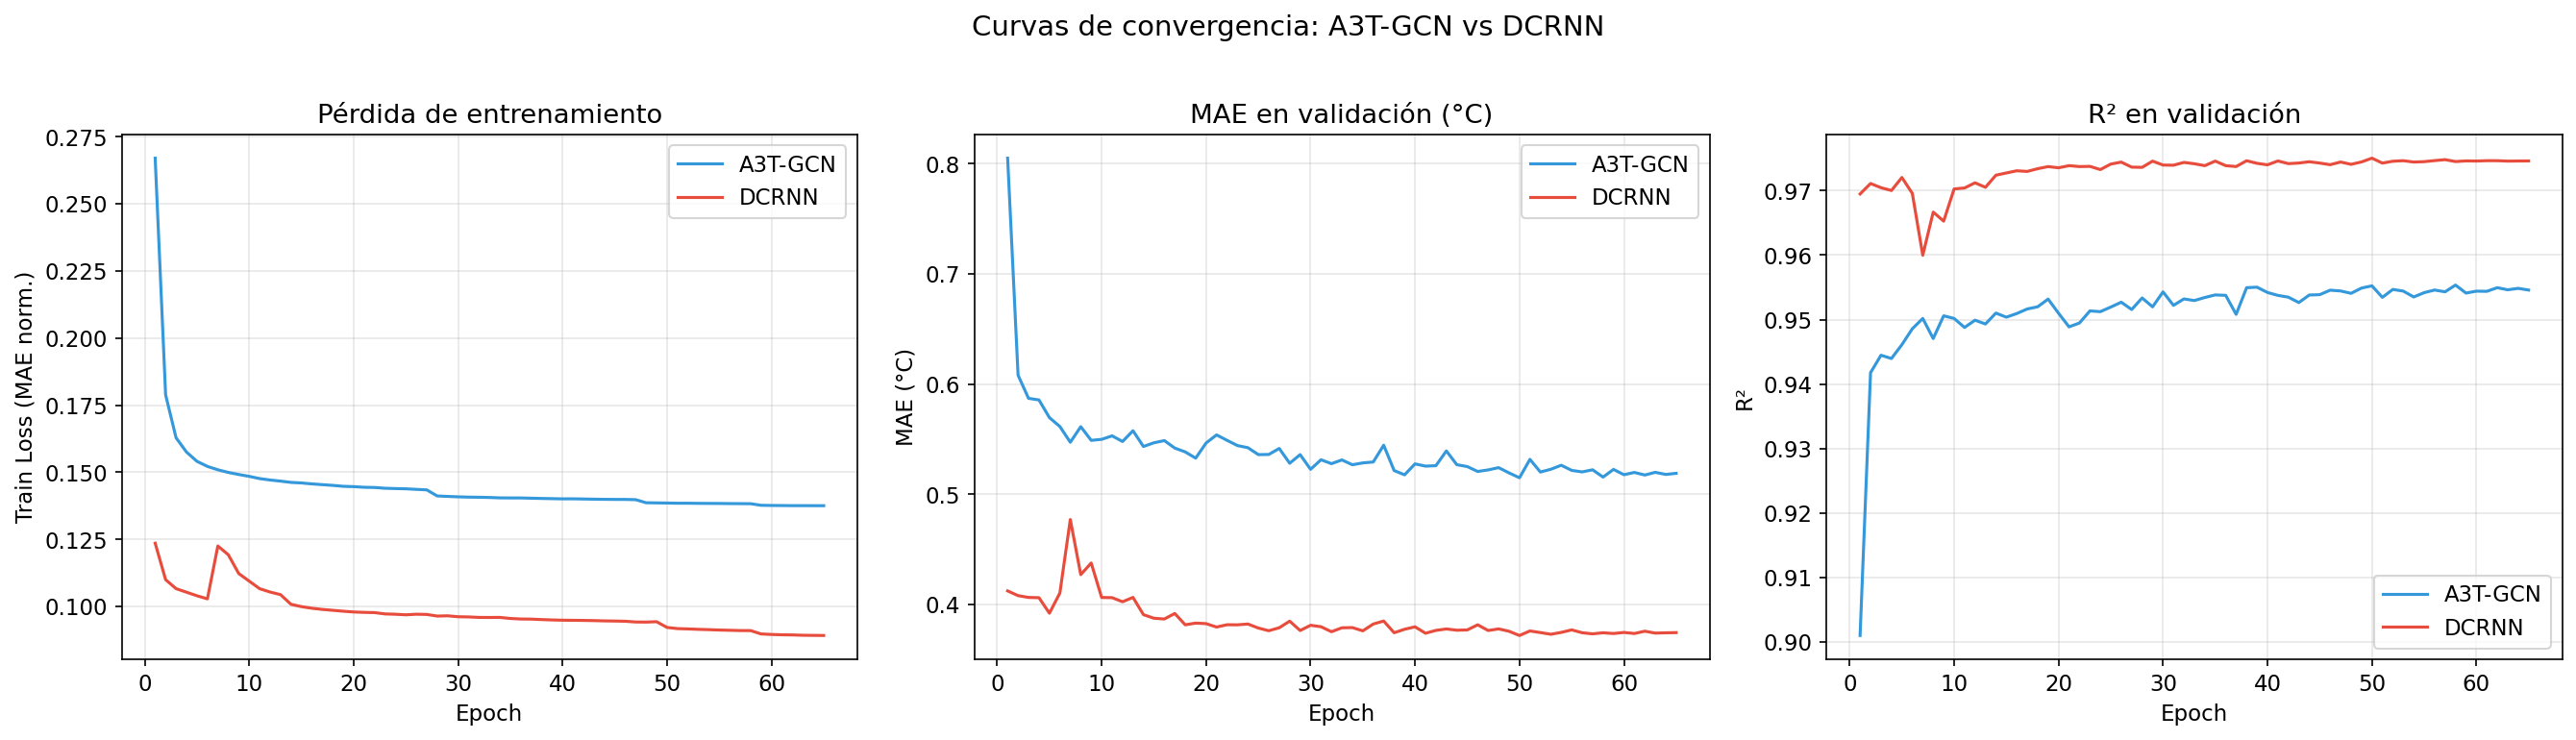

Guardado: convergencia.png

3. PREDICCIÓN VS REAL


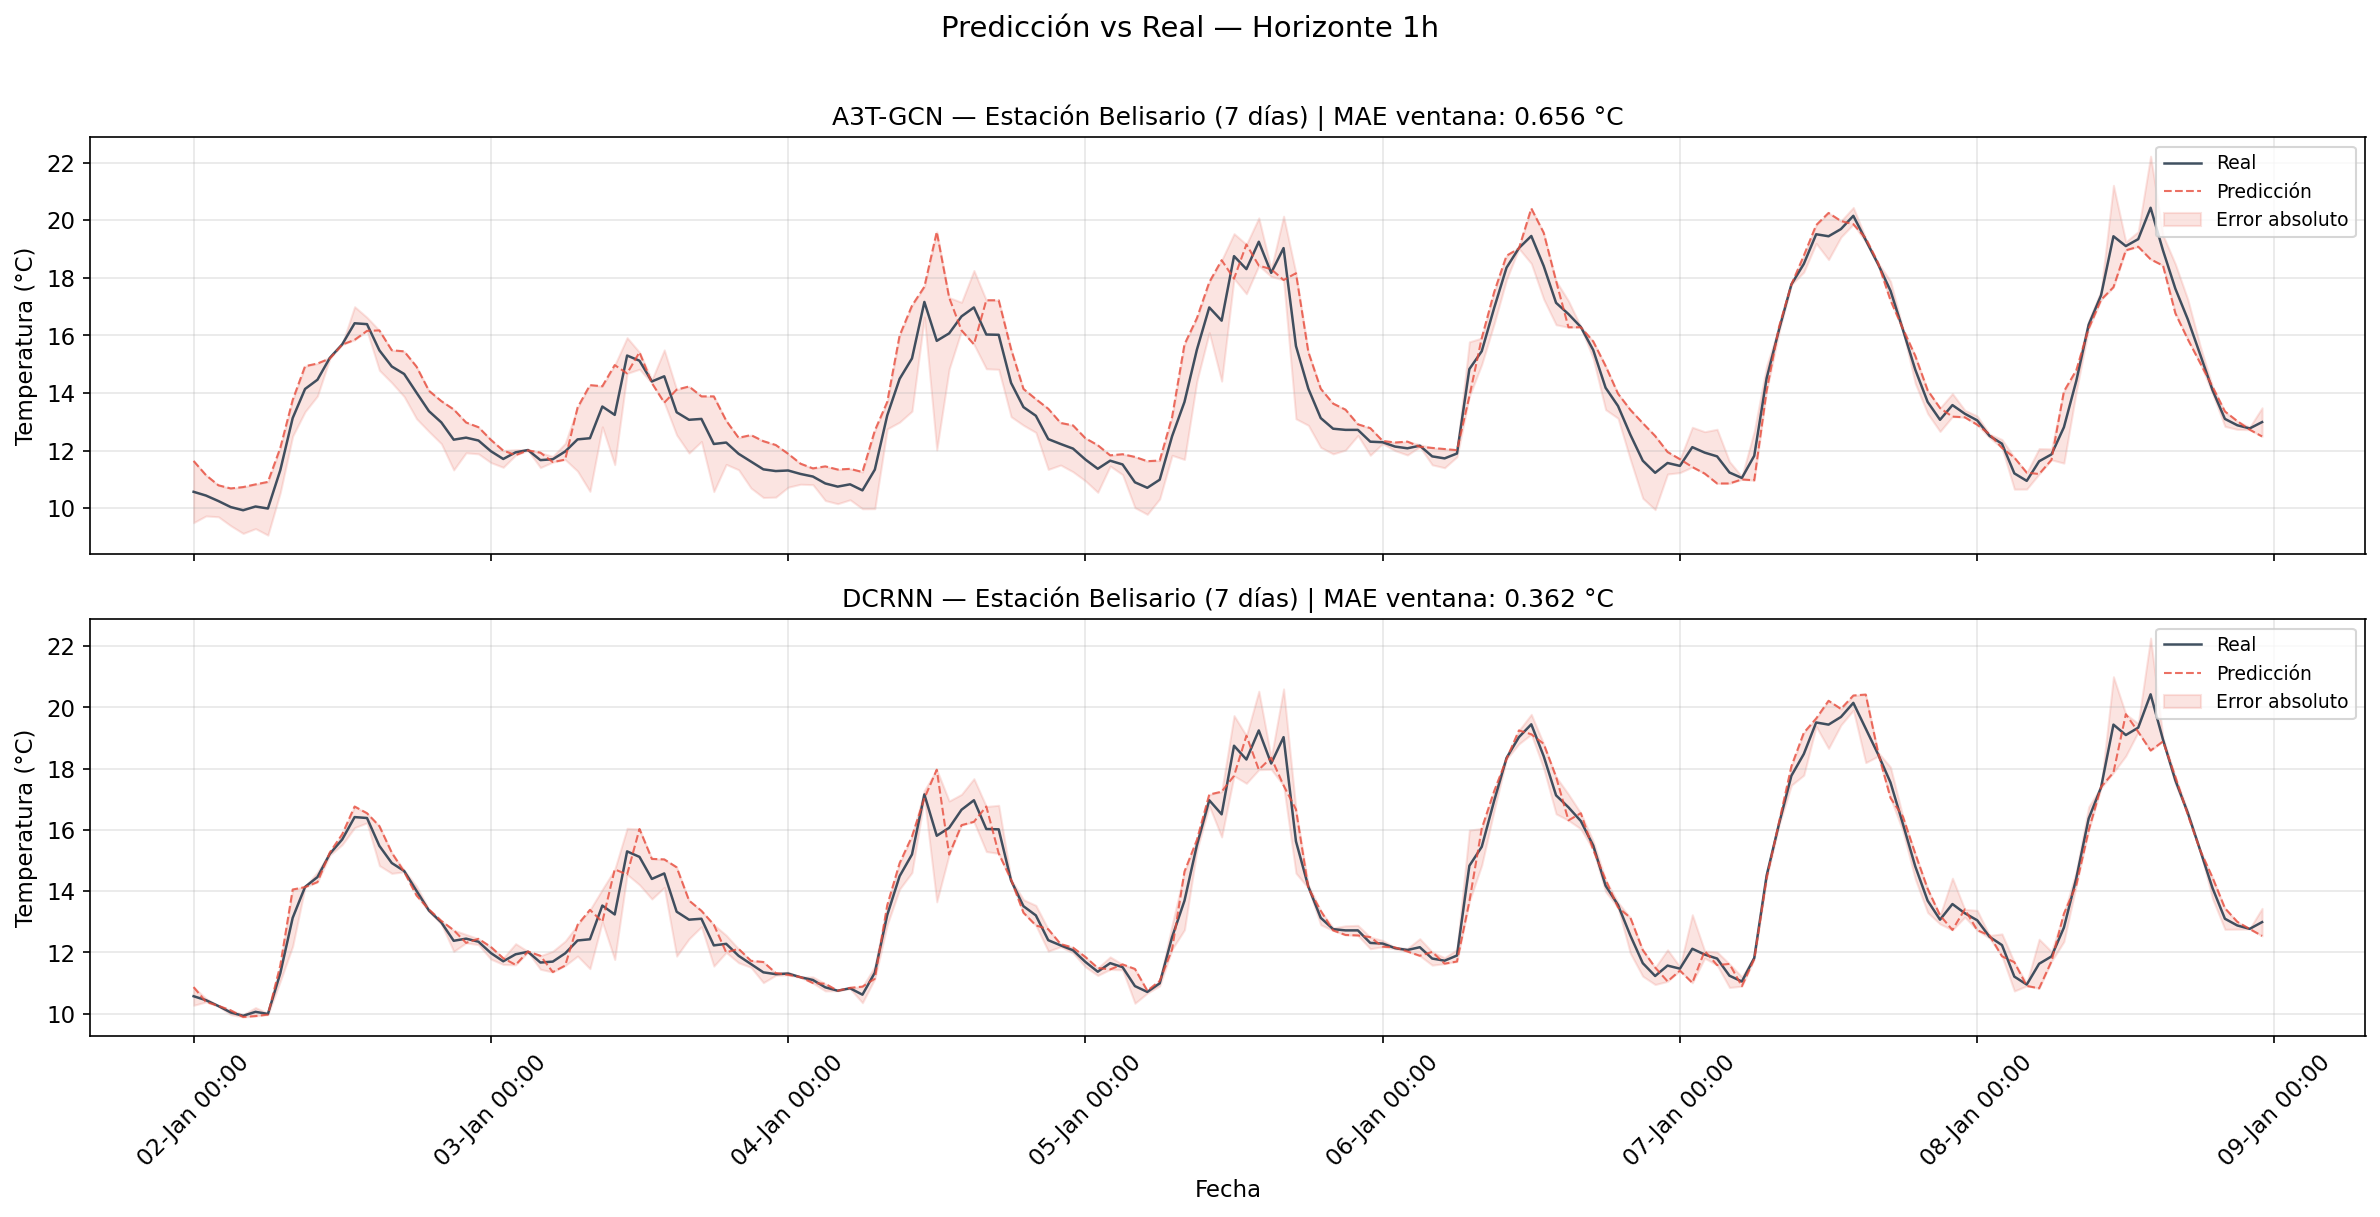

Guardado: prediccion_vs_real_Belisario_7d.png

4. SCATTER PLOT


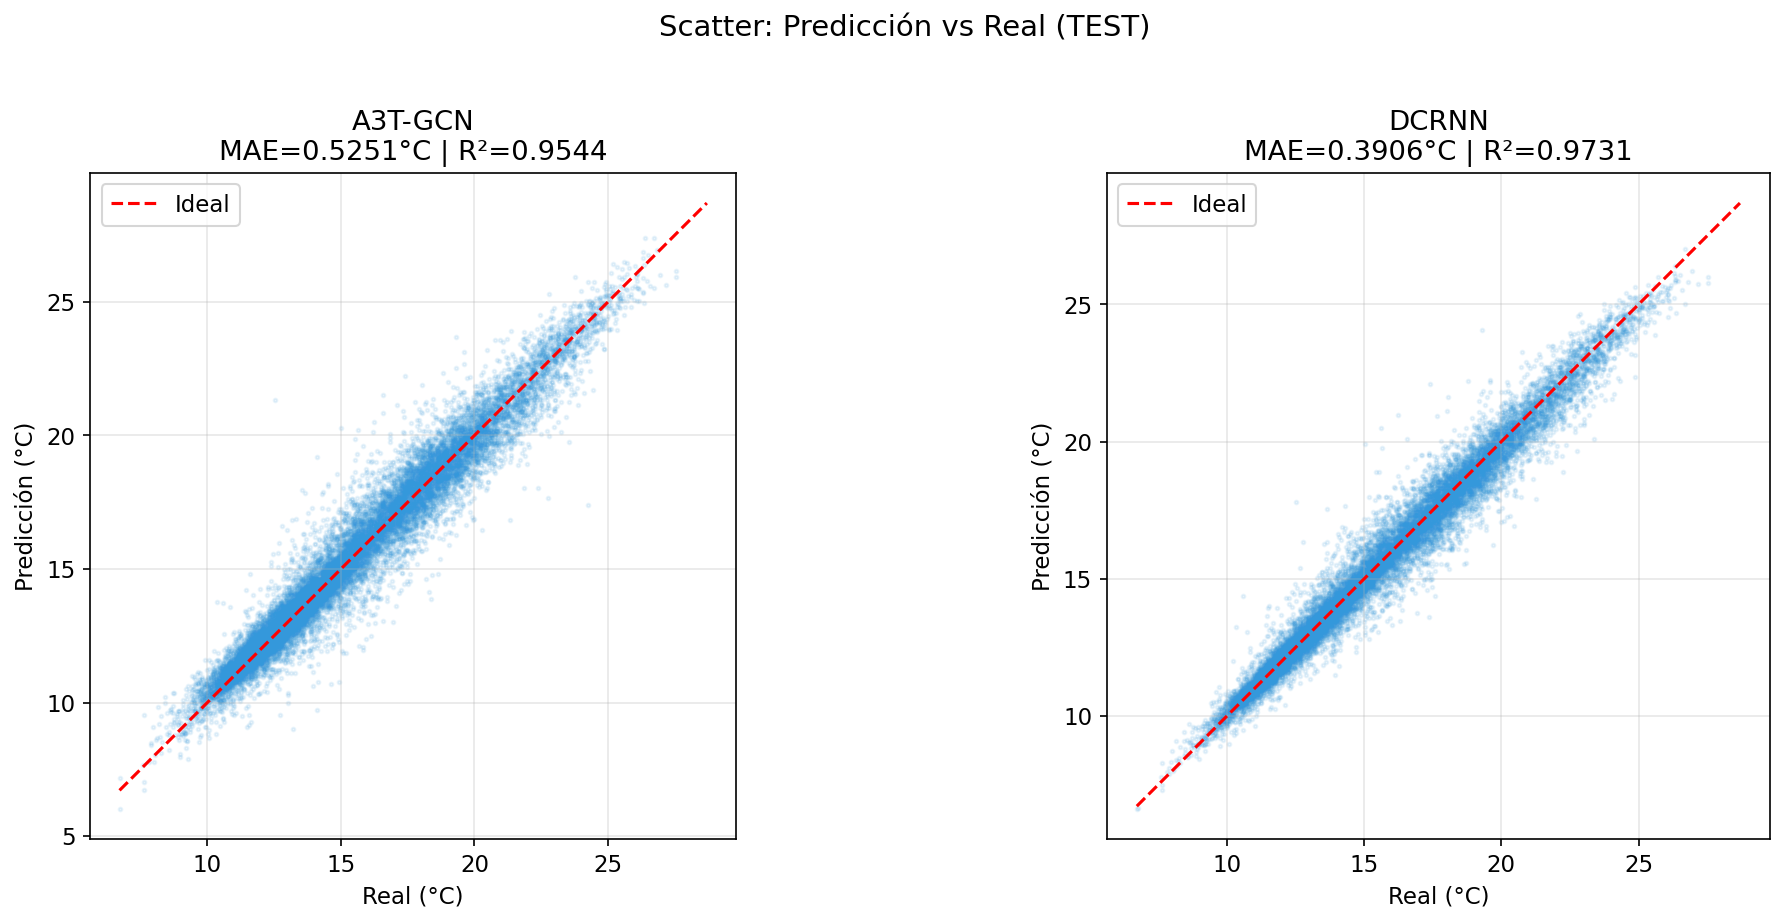

Guardado: scatter_pred_vs_real.png

5. ERROR POR ESTACIÓN


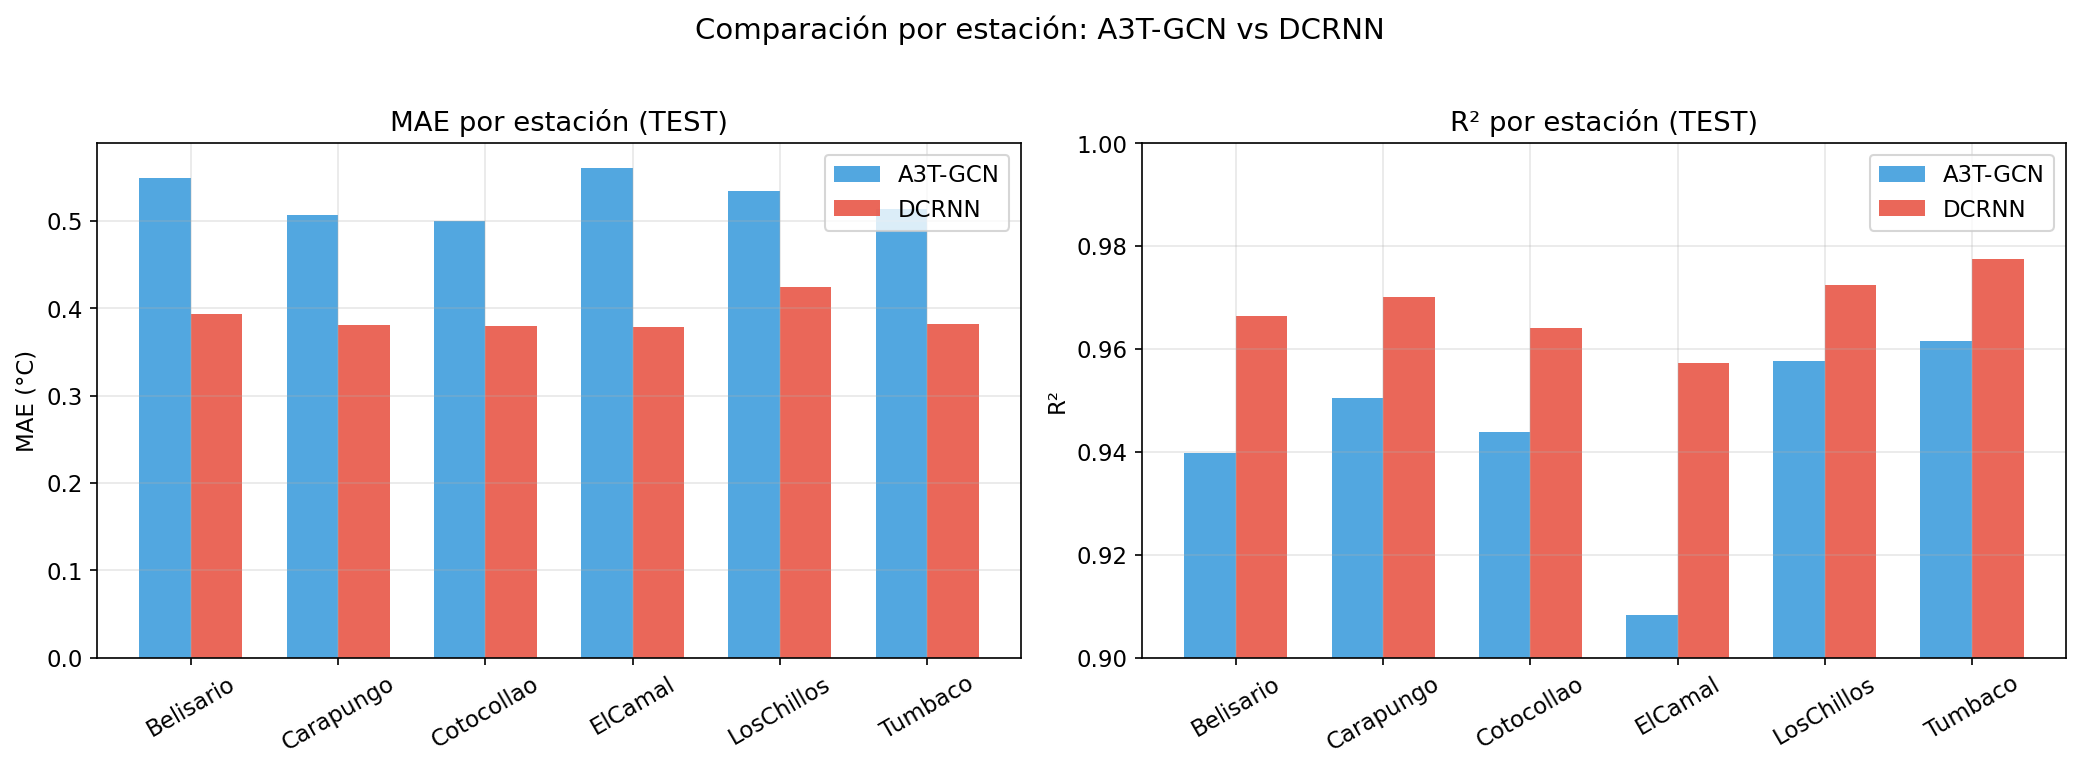

Guardado: error_por_estacion.png

Tablas guardadas: metricas_comparativas.csv, metricas_por_estacion.csv


In [2]:
"""
Evaluación comparativa A3T-GCN vs DCRNN - REMMAQ
  1. Tablas de métricas por split (train, val, test)
  2. Curvas de convergencia (loss y MAE por epoch)
  3. Predicción vs real (serie temporal)
  4. Scatter plot pred vs real
  5. Error por estación
"""

import numpy as np
import pandas as pd
import pickle
import torch
import torch.nn as nn
from torch.cuda.amp import autocast
from torch.utils.data import Dataset, DataLoader
from torch_geometric_temporal.nn.recurrent import A3TGCN, DCRNN
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 150,
    "savefig.dpi": 150
})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

STATIONS = ["Belisario", "Carapungo", "Cotocollao", "ElCamal", "LosChillos", "Tumbaco"]
VARIABLES_FULL = [
    "direccionViento", "humedadRelativa", "ozono", "precipitacion",
    "presionBarometrica", "radiacionSolar", "temperaturaMedia", "velocidadViento",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos"
]

CONFIG = {
    "n_nodes": 6, "in_channels": 14, "hidden": 64,
    "seq_len": 24, "horizon": 1, "target_idx": 6, "batch_size": 32,
}


# ============================================================
# DATASET Y BATCHING (reutilizado)
# ============================================================
class STGNNDataset(Dataset):
    def __init__(self, data, mask, seq_len, horizon, target_idx):
        self.data = data; self.mask = mask
        self.seq_len = seq_len; self.horizon = horizon
        self.target_idx = target_idx
        self.n_samples = data.shape[0] - seq_len - horizon + 1
    def __len__(self): return self.n_samples
    def __getitem__(self, i):
        X = self.data[i:i+self.seq_len]
        y = self.data[i+self.seq_len:i+self.seq_len+self.horizon, :, self.target_idx]
        m = self.mask[i+self.seq_len:i+self.seq_len+self.horizon, :, self.target_idx]
        return (torch.tensor(X, dtype=torch.float32),
                torch.tensor(y, dtype=torch.float32),
                torch.tensor(m, dtype=torch.float32))

def batch_edge_index(edge_index, batch_size, n_nodes):
    return torch.cat([edge_index + i * n_nodes for i in range(batch_size)], dim=1)

def batch_edge_weight(edge_weight, batch_size):
    return edge_weight.repeat(batch_size)


# ============================================================
# MODELOS
# ============================================================
class A3TGCNForecaster(nn.Module):
    def __init__(self, in_channels, hidden, horizon, periods):
        super().__init__()
        self.tgnn = A3TGCN(in_channels=in_channels, out_channels=hidden, periods=periods)
        self.head = nn.Linear(hidden, horizon)
    def forward(self, x, edge_index, edge_weight):
        h = self.tgnn(x, edge_index, edge_weight)
        return self.head(h)

class DCRNNForecaster(nn.Module):
    def __init__(self, in_channels, hidden, horizon, K=2):
        super().__init__()
        self.dcrnn = DCRNN(in_channels=in_channels, out_channels=hidden, K=K)
        self.head = nn.Linear(hidden, horizon)
    def forward(self, x_seq, edge_index, edge_weight):
        h = None
        for t in range(x_seq.size(0)):
            h = self.dcrnn(x_seq[t], edge_index, edge_weight, H=h)
        return self.head(h)


# ============================================================
# PREDICCIÓN COMPLETA
# ============================================================
@torch.no_grad()
def predict_all(model, model_type, loader, edge_index, edge_weight, n_nodes):
    """Genera predicciones para todo un split.
    Retorna pred, target, mask como arrays numpy."""
    model.eval()
    all_pred, all_target, all_mask = [], [], []

    for X, y, m in loader:
        bs = X.size(0)
        X = X.to(DEVICE)
        ei = batch_edge_index(edge_index, bs, n_nodes).to(DEVICE)
        ew = batch_edge_weight(edge_weight, bs).to(DEVICE)

        with autocast():
            if model_type == "a3tgcn":
                x_in = X.permute(0, 2, 3, 1).reshape(bs * n_nodes, -1, X.size(1))
            else:  # dcrnn
                x_in = X.permute(1, 0, 2, 3).reshape(X.size(1), bs * n_nodes, -1)

            out = model(x_in, ei, ew)
            out = out.reshape(bs, n_nodes, -1).permute(0, 2, 1)

        all_pred.append(out.cpu().numpy())
        all_target.append(y.numpy())
        all_mask.append(m.numpy())

    return np.concatenate(all_pred), np.concatenate(all_target), np.concatenate(all_mask)


def compute_metrics(pred, target, mask):
    """Calcula métricas en valores ya desnormalizados."""
    m = mask.flatten().astype(bool)
    p = pred.flatten()[m]
    t = target.flatten()[m]
    mae = np.mean(np.abs(t - p))
    rmse = np.sqrt(np.mean((t - p) ** 2))
    ss_res = np.sum((t - p) ** 2)
    ss_tot = np.sum((t - t.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return {"MAE": mae, "RMSE": rmse, "R2": r2}


def compute_metrics_per_station(pred, target, mask, stations):
    """Métricas por estación."""
    results = []
    for i, st in enumerate(stations):
        m = mask[:, :, i].flatten().astype(bool)
        p = pred[:, :, i].flatten()[m]
        t = target[:, :, i].flatten()[m]
        if len(t) == 0:
            continue
        mae = np.mean(np.abs(t - p))
        rmse = np.sqrt(np.mean((t - p) ** 2))
        ss_res = np.sum((t - p) ** 2)
        ss_tot = np.sum((t - t.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        results.append({"estacion": st, "MAE": mae, "RMSE": rmse, "R2": r2})
    return pd.DataFrame(results)


def denorm(values, scalers, target_idx):
    sc = scalers[target_idx]
    return sc.inverse_transform(values.reshape(-1, 1)).flatten()


# ============================================================
# 1. TABLAS DE MÉTRICAS
# ============================================================
def generar_tablas(modelos, loaders, edge_index, edge_weight, scalers, cfg):
    print("\n" + "=" * 80)
    print("TABLA COMPARATIVA DE MÉTRICAS (°C)")
    print("=" * 80)

    resultados_globales = []
    resultados_estacion = {}

    for nombre, model, mtype in modelos:
        for split in ["train", "val", "test"]:
            pred, target, mask = predict_all(
                model, mtype, loaders[split], edge_index, edge_weight, cfg["n_nodes"]
            )
            # Desnormalizar
            pred_r = denorm(pred, scalers, cfg["target_idx"]).reshape(pred.shape)
            target_r = denorm(target, scalers, cfg["target_idx"]).reshape(target.shape)

            m_global = compute_metrics(pred_r, target_r, mask)
            resultados_globales.append({
                "Modelo": nombre, "Split": split,
                "MAE (°C)": round(m_global["MAE"], 4),
                "RMSE (°C)": round(m_global["RMSE"], 4),
                "R²": round(m_global["R2"], 4),
            })

            if split == "test":
                df_st = compute_metrics_per_station(pred_r, target_r, mask, STATIONS)
                df_st["Modelo"] = nombre
                resultados_estacion[nombre] = df_st

    # Tabla global
    df_global = pd.DataFrame(resultados_globales)
    print("\nMétricas globales:")
    print(df_global.to_string(index=False))

    # Tabla por estación (test)
    print("\nMétricas por estación (TEST):")
    df_est = pd.concat(resultados_estacion.values())
    pivot_mae = df_est.pivot(index="estacion", columns="Modelo", values="MAE").round(4)
    pivot_r2 = df_est.pivot(index="estacion", columns="Modelo", values="R2").round(4)
    print("\nMAE (°C) por estación:")
    print(pivot_mae)
    print("\nR² por estación:")
    print(pivot_r2)

    return df_global, df_est


# ============================================================
# 2. CURVAS DE CONVERGENCIA
# ============================================================
def graficar_convergencia(historiales):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for nombre, hist, color in historiales:
        axes[0].plot(hist["epoch"], hist["train_loss"], label=nombre, color=color, linewidth=1.5)
        axes[1].plot(hist["epoch"], hist["val_MAE_C"], label=nombre, color=color, linewidth=1.5)
        axes[2].plot(hist["epoch"], hist["val_R2"], label=nombre, color=color, linewidth=1.5)

    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train Loss (MAE norm.)")
    axes[0].set_title("Pérdida de entrenamiento"); axes[0].legend()

    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (°C)")
    axes[1].set_title("MAE en validación (°C)"); axes[1].legend()

    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("R²")
    axes[2].set_title("R² en validación"); axes[2].legend()

    plt.suptitle("Curvas de convergencia: A3T-GCN vs DCRNN", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("convergencia.png")
    plt.show()
    print("Guardado: convergencia.png")


# ============================================================
# 3. PREDICCIÓN VS REAL (serie temporal)
# ============================================================
def graficar_prediccion_vs_real(modelos, loaders, edge_index, edge_weight,
                                 scalers, idx_test, cfg, dias=7, estacion_idx=0):
    """Grafica predicción vs real para N días en una estación."""

    estacion = STATIONS[estacion_idx]
    horas = dias * 24

    fig, axes = plt.subplots(len(modelos), 1, figsize=(16, 4 * len(modelos)), sharex=True)
    if len(modelos) == 1:
        axes = [axes]

    for ax, (nombre, model, mtype) in zip(axes, modelos):
        pred, target, mask = predict_all(
            model, mtype, loaders["test"], edge_index, edge_weight, cfg["n_nodes"]
        )
        pred_r = denorm(pred, scalers, cfg["target_idx"]).reshape(pred.shape)
        target_r = denorm(target, scalers, cfg["target_idx"]).reshape(target.shape)

        # Extraer estación y primeros N días
        t_real = target_r[:horas, 0, estacion_idx]
        t_pred = pred_r[:horas, 0, estacion_idx]
        m = mask[:horas, 0, estacion_idx].astype(bool)
        fechas = idx_test[cfg["seq_len"]:cfg["seq_len"] + horas]

        # Serie real
        ax.plot(fechas, t_real, color="#2c3e50", linewidth=1.2, label="Real", alpha=0.9)
        # Serie predicha (solo donde mask=1)
        pred_plot = np.where(m, t_pred, np.nan)
        ax.plot(fechas, pred_plot, color="#e74c3c", linewidth=1.0, label="Predicción",
                alpha=0.8, linestyle="--")

        # Error sombreado
        error = np.abs(t_real - t_pred) * m
        ax.fill_between(fechas, t_real - error, t_real + error,
                        alpha=0.15, color="#e74c3c", label="Error absoluto")

        # MAE en esta ventana
        mae_ventana = np.mean(np.abs(t_real[m] - t_pred[m]))
        ax.set_title(f"{nombre} — Estación {estacion} ({dias} días) | MAE ventana: {mae_ventana:.3f} °C",
                     fontsize=12)
        ax.set_ylabel("Temperatura (°C)")
        ax.legend(loc="upper right", fontsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %H:%M"))
        ax.xaxis.set_major_locator(mdates.DayLocator())

    plt.xlabel("Fecha")
    plt.xticks(rotation=45)
    plt.suptitle(f"Predicción vs Real — Horizonte {cfg['horizon']}h", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f"prediccion_vs_real_{estacion}_{dias}d.png")
    plt.show()
    print(f"Guardado: prediccion_vs_real_{estacion}_{dias}d.png")


# ============================================================
# 4. SCATTER PLOT (predicción vs real)
# ============================================================
def graficar_scatter(modelos, loaders, edge_index, edge_weight, scalers, cfg):
    fig, axes = plt.subplots(1, len(modelos), figsize=(7 * len(modelos), 6))
    if len(modelos) == 1:
        axes = [axes]

    for ax, (nombre, model, mtype) in zip(axes, modelos):
        pred, target, mask = predict_all(
            model, mtype, loaders["test"], edge_index, edge_weight, cfg["n_nodes"]
        )
        pred_r = denorm(pred, scalers, cfg["target_idx"]).flatten()
        target_r = denorm(target, scalers, cfg["target_idx"]).flatten()
        m = mask.flatten().astype(bool)

        p, t = pred_r[m], target_r[m]

        # Submuestrear para visualización (si hay muchos puntos)
        if len(p) > 20000:
            rng = np.random.RandomState(42)
            idx = rng.choice(len(p), 20000, replace=False)
            p_plot, t_plot = p[idx], t[idx]
        else:
            p_plot, t_plot = p, t

        ax.scatter(t_plot, p_plot, alpha=0.1, s=3, color="#3498db")
        ax.plot([t.min(), t.max()], [t.min(), t.max()], "r--", linewidth=1.5, label="Ideal")

        mae = np.mean(np.abs(t - p))
        r2 = 1 - np.sum((t - p) ** 2) / np.sum((t - t.mean()) ** 2)

        ax.set_xlabel("Real (°C)"); ax.set_ylabel("Predicción (°C)")
        ax.set_title(f"{nombre}\nMAE={mae:.4f}°C | R²={r2:.4f}")
        ax.legend()
        ax.set_aspect("equal", adjustable="box")

    plt.suptitle("Scatter: Predicción vs Real (TEST)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("scatter_pred_vs_real.png")
    plt.show()
    print("Guardado: scatter_pred_vs_real.png")


# ============================================================
# 5. ERROR POR ESTACIÓN (barplot)
# ============================================================
def graficar_error_por_estacion(df_est):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    modelos_nombres = df_est["Modelo"].unique()
    x = np.arange(len(STATIONS))
    width = 0.35
    colors = ["#3498db", "#e74c3c"]

    for i, nombre in enumerate(modelos_nombres):
        sub = df_est[df_est["Modelo"] == nombre].set_index("estacion").reindex(STATIONS)
        axes[0].bar(x + i * width, sub["MAE"], width, label=nombre, color=colors[i], alpha=0.85)
        axes[1].bar(x + i * width, sub["R2"], width, label=nombre, color=colors[i], alpha=0.85)

    axes[0].set_xticks(x + width / 2); axes[0].set_xticklabels(STATIONS, rotation=30)
    axes[0].set_ylabel("MAE (°C)"); axes[0].set_title("MAE por estación (TEST)")
    axes[0].legend()

    axes[1].set_xticks(x + width / 2); axes[1].set_xticklabels(STATIONS, rotation=30)
    axes[1].set_ylabel("R²"); axes[1].set_title("R² por estación (TEST)")
    axes[1].legend(); axes[1].set_ylim(0.90, 1.0)

    plt.suptitle("Comparación por estación: A3T-GCN vs DCRNN", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("error_por_estacion.png")
    plt.show()
    print("Guardado: error_por_estacion.png")


# ============================================================
# EJECUCIÓN
# ============================================================
if __name__ == "__main__":
    print("Cargando artefactos...")

    edge_index = torch.load("edge_index.pt")
    edge_weight = torch.load("edge_weight.pt")
    with open("scalers.pkl", "rb") as f:
        scalers = pickle.load(f)

    idx_test = pd.DatetimeIndex(np.load("idx_temporal.npy"))
    # Recortar al split test (2024-01-01 en adelante)
    idx_test = idx_test[idx_test >= "2024-01-01"]

    loaders = {}
    for split in ["train", "val", "test"]:
        data = np.load(f"tensor_{split}.npy")
        mask = np.load(f"mask_{split}.npy")
        ds = STGNNDataset(data, mask, CONFIG["seq_len"], CONFIG["horizon"], CONFIG["target_idx"])
        loaders[split] = DataLoader(ds, batch_size=CONFIG["batch_size"],
                                     shuffle=False, num_workers=2, pin_memory=True)

    # Cargar modelos
    model_a3t = A3TGCNForecaster(14, 64, 1, 24).to(DEVICE)
    model_a3t.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))

    model_dcrnn = DCRNNForecaster(14, 64, 1, K=2).to(DEVICE)
    model_dcrnn.load_state_dict(torch.load("best_model_dcrnn.pt", map_location=DEVICE))

    modelos = [
        ("A3T-GCN", model_a3t, "a3tgcn"),
        ("DCRNN", model_dcrnn, "dcrnn"),
    ]

    # Cargar historiales
    hist_a3t = pd.read_csv("training_history.csv")
    hist_dcrnn = pd.read_csv("training_history_dcrnn.csv")

    # --- 1. Tablas de métricas ---
    print("\n1. TABLAS DE MÉTRICAS")
    df_global, df_est = generar_tablas(modelos, loaders, edge_index, edge_weight, scalers, CONFIG)

    # --- 2. Curvas de convergencia ---
    print("\n2. CURVAS DE CONVERGENCIA")
    graficar_convergencia([
        ("A3T-GCN", hist_a3t, "#3498db"),
        ("DCRNN", hist_dcrnn, "#e74c3c"),
    ])

    # --- 3. Predicción vs real (7 días, estación Belisario) ---
    print("\n3. PREDICCIÓN VS REAL")
    graficar_prediccion_vs_real(
        modelos, loaders, edge_index, edge_weight,
        scalers, idx_test, CONFIG, dias=7, estacion_idx=0
    )

    # --- 4. Scatter plot ---
    print("\n4. SCATTER PLOT")
    graficar_scatter(modelos, loaders, edge_index, edge_weight, scalers, CONFIG)

    # --- 5. Error por estación ---
    print("\n5. ERROR POR ESTACIÓN")
    graficar_error_por_estacion(df_est)

    # Guardar tablas
    df_global.to_csv("metricas_comparativas.csv", index=False)
    df_est.to_csv("metricas_por_estacion.csv", index=False)
    print("\nTablas guardadas: metricas_comparativas.csv, metricas_por_estacion.csv")